<a href="https://colab.research.google.com/github/jayacharan18/DST-E_RECORD-LAB/blob/main/Dstexp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mall_Customers.csv not found. Using a dummy DataFrame for demonstration.
Explained Variance Ratio: [0.6689216  0.33077843]


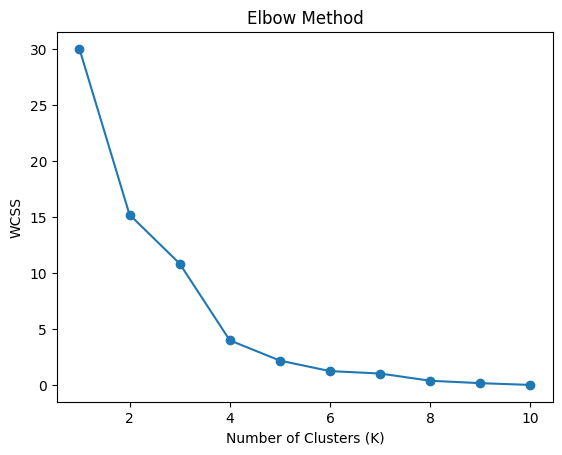

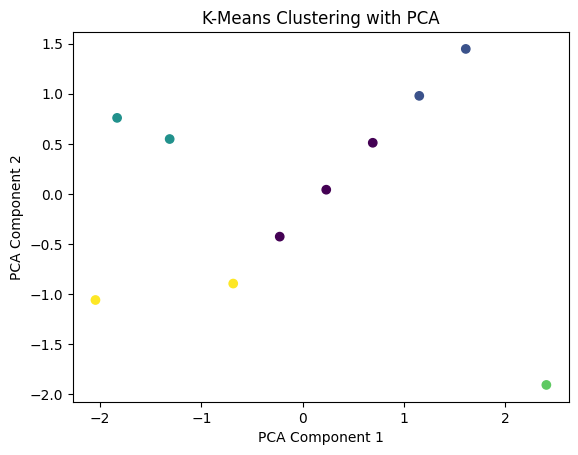

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Load dataset
try:
    data = pd.read_csv("Mall_Customers.csv")
except FileNotFoundError:
    print("Mall_Customers.csv not found. Using a dummy DataFrame for demonstration.")
    # Create a dummy DataFrame with similar column names for demonstration
    dummy_data = {
        'Age': [20, 25, 30, 35, 40, 45, 50, 55, 60, 65],
        'Annual Income (k$)': [15, 20, 30, 40, 50, 60, 70, 80, 90, 100],
        'Spending Score (1-100)': [39, 81, 75, 40, 50, 60, 70, 80, 90, 10]
    }
    data = pd.DataFrame(dummy_data)
# Select numerical features
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
# Elbow Method
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
# Plot Elbow Graph
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()
# Apply KMeans with optimal K (example K = 5
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X_pca)
# Plot Clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("K-Means Clustering with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
#--- STEP 1: LOAD DATA (Creating a dummy dataset for the lab) --
data = {
'Country': ['India', 'USA', 'India', 'USA', 'UK', 'India'],
'Age': [22, 25, np.nan, 30, 28, 35], # Note the 'nan' (missing value)
'Salary': [40000, 60000, 50000, np.nan, 72000, 58000],
'Purchased': ['No', 'Yes', 'Yes', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)
print("--- ORIGINAL RAW DATA ---")
print(df)
print("\n")
#--- STEP 2: INSPECT DATA
# Check for missing values
print("--- MISSING VALUES COUNT ---")
print(df.isnull().sum())
print("\n")
#--- STEP 3: CLEAN DATA (Handling Missing Values)
# Logic: Fill missing Age/Salary with the Average (Mean) of that column
df['Age'] = df['Age'].fillna (df['Age'].mean())
df['Salary'] = df['Salary'].fillna (df['Salary'].mean())
print("--- DATA AFTER CLEANING ---")
print(df)
print("\n")
# --- STEP 4: CONVERT TEXT TO NUMBERS (Encoding)
# Logic: Machines can't read 'India' or 'USA'. We convert them to Os and 1s.
# We use 'One Hot Encoding' (get_dummies)
df_encoded = pd.get_dummies (df, columns=['Country'])
# For the Target column (Purchased), let's map Yes/No manually
df_encoded['Purchased'] = df_encoded['Purchased'].map({'Yes': 1, 'No': 0})
print("--- DATA AFTER ENCODING (All Numbers Now) ---")
print(df_encoded)
print("\n")
#--- STEP 5: SCALE FEATURES ---
# Logic: Age is 20-30, Salary is 40000-60000. Salary dominates Age because it's bigger.
# We shrink them to the same scale.
# Separate Features (X) and Target (y)
X = df_encoded.drop('Purchased', axis=1)
y = df_encoded['Purchased']
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("--- FINAL PROCESSED DATA (Ready for Al) ---")
print(pd.DataFrame(X_scaled, columns=X.columns).head())

--- ORIGINAL RAW DATA ---
  Country   Age   Salary Purchased
0   India  22.0  40000.0        No
1     USA  25.0  60000.0       Yes
2   India   NaN  50000.0       Yes
3     USA  30.0      NaN        No
4      UK  28.0  72000.0       Yes
5   India  35.0  58000.0       Yes


--- MISSING VALUES COUNT ---
Country      0
Age          1
Salary       1
Purchased    0
dtype: int64


--- DATA AFTER CLEANING ---
  Country   Age   Salary Purchased
0   India  22.0  40000.0        No
1     USA  25.0  60000.0       Yes
2   India  28.0  50000.0       Yes
3     USA  30.0  56000.0        No
4      UK  28.0  72000.0       Yes
5   India  35.0  58000.0       Yes


--- DATA AFTER ENCODING (All Numbers Now) ---
    Age   Salary  Purchased  Country_India  Country_UK  Country_USA
0  22.0  40000.0          0           True       False        False
1  25.0  60000.0          1          False       False         True
2  28.0  50000.0          1           True       False        False
3  30.0  56000.0          0   

In [3]:
 Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#2. Load Dataset
data = load_breast_cancer()
X = data.data
Y = data.target

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
X, Y, test_size=0.2, random_state=42)

#4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#5. Normal Logistic Regression (Very Large C)
normal_model = LogisticRegression(C=1e6, penalty='l2', solver='liblinear')
normal_model.fit(X_train_scaled, y_train)
normal_pred = normal_model.predict(X_test_scaled)
normal_acc = accuracy_score(y_test, normal_pred)

#6. Regularized Logistic Regression
regularized_model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
regularized_model.fit(X_train_scaled, y_train)
reg_pred = regularized_model.predict(X_test_scaled)
reg_acc = accuracy_score(y_test, reg_pred)

#7. Print Results
print("Normal Logistic Accuracy:", normal_acc * 100)
print("Regularized Logistic Accuracy:", reg_acc * 100)

#8. Compare Coefficients
plt.figure()
plt.plot(normal_model.coef_.flatten(), label='Normal Logistic')
plt.plot(regularized_model.coef_.flatten(), label='Regularized Logistic')
plt.legend()
plt.title("Coefficient Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.show()

#9. Accuracy Comparison Bar Graph
plt.figure()
models = ['Normal Logistic', 'Regularized Logistic']
accuracies = [normal_acc, reg_acc]
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

SyntaxError: invalid syntax (1819122479.py, line 1)

In [5]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


Normal Logistic Accuracy: 93.85964912280701
Regularized Logistic Accuracy: 99.12280701754386


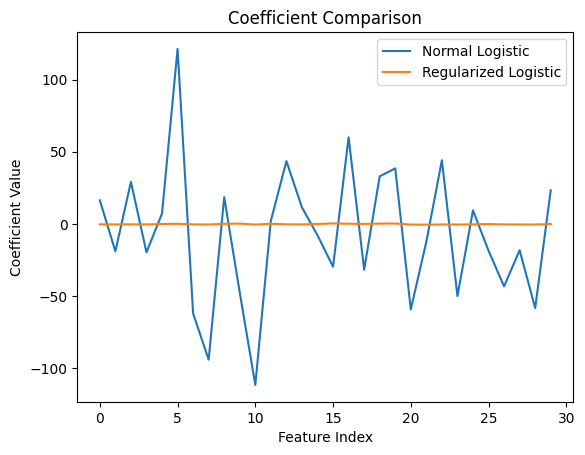

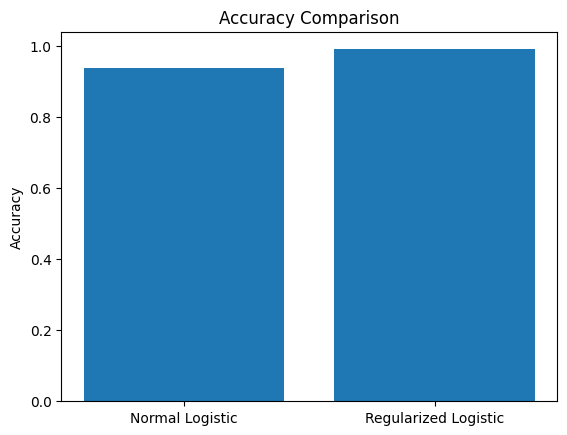

In [6]:
#1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#2. Load Dataset
data = load_breast_cancer()
X = data.data
Y = data.target

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
X, Y, test_size=0.2, random_state=42)

#4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#5. Normal Logistic Regression (Very Large C)
normal_model = LogisticRegression(C=1e6, penalty='l2', solver='liblinear')
normal_model.fit(X_train_scaled, y_train)
normal_pred = normal_model.predict(X_test_scaled)
normal_acc = accuracy_score(y_test, normal_pred)

#6. Regularized Logistic Regression
regularized_model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
regularized_model.fit(X_train_scaled, y_train)
reg_pred = regularized_model.predict(X_test_scaled)
reg_acc = accuracy_score(y_test, reg_pred)

#7. Print Results
print("Normal Logistic Accuracy:", normal_acc * 100)
print("Regularized Logistic Accuracy:", reg_acc * 100)

#8. Compare Coefficients
plt.figure()
plt.plot(normal_model.coef_.flatten(), label='Normal Logistic')
plt.plot(regularized_model.coef_.flatten(), label='Regularized Logistic')
plt.legend()
plt.title("Coefficient Comparison")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.show()

#9. Accuracy Comparison Bar Graph
plt.figure()
models = ['Normal Logistic', 'Regularized Logistic']
accuracies = [normal_acc, reg_acc]
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()